In [1]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from functools import lru_cache
from dataclasses import replace

from config import SimConfig
from src.data_processing import load_and_cache_entire_fleet, downsample_block_mean, fit_dtmc
from src.utils.evaluation import VoyageBenchmarker
from src.plants.hybrid_plant import calculate_fc_cost_per_second

In [2]:
# --- 1. INITIALIZATION ---
fleet_cache = load_and_cache_entire_fleet()
benchmarker = VoyageBenchmarker(fleet_cache)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [3]:
# --- 2. CACHED MARKOV ENGINE (The "Slow" Recompute) ---
# We use lru_cache so that if the user only changes k_fc or tolerance, 
# we don't re-read the data or re-fit the DTMC.
# Note: training_days must be cast to a tuple because lists are unhashable.
@lru_cache(maxsize=16)
def _build_markov_matrix(train_days_tuple: tuple, n_states: int, Ts: int, alpha: float):
    train_t, train_pd = [], []
    for d in train_days_tuple:
        data = fleet_cache[d]
        t_off = train_t[-1][-1] if train_t else 0.0
        train_t.append(data['t'] + t_off)
        train_pd.append(data['Pd'])
    
    t_concat = np.concatenate(train_t)
    pd_concat = np.concatenate(train_pd)

    ds_train_macro = downsample_block_mean(t_concat, pd_concat, Ts, align='t0')
    mc_macro = fit_dtmc(ds_train_macro['Pd'], n_states, alpha)
    
    return mc_macro['levels'], mc_macro.get('P', mc_macro.get('trans_mat'))

In [4]:
# --- 3. PHYSICS & HEURISTICS ENGINE (The "Fast" Recompute) ---
def get_heuristic_matrices(train_days: list, config: SimConfig, tolerance: int = 1):
    # 1. Fetch the cached Markov elements
    p_vals, trans_matrix = _build_markov_matrix(
        tuple(train_days), config.n_states, config.Ts, config.alpha
    )
    n_vals = config.n_vals

    # 2. Build Cost Matrix
    cost_matrix = np.zeros((len(n_vals), len(p_vals)))
    for i, n_val in enumerate(n_vals):
        for j, p_val in enumerate(p_vals):
            p_module = p_val / n_val
            module_cost = calculate_fc_cost_per_second(
                p_module, config.p_nom, config.k_h2, config.k_fc, 
                config.tau_fc, config.a0, config.a1, config.a2, config.alpha_deg
            )
            cost_matrix[i, j] = module_cost * n_val
            
    # 3. Define Top-M Comfort Zones
    K_zones = {j: [] for j in range(len(n_vals))}
    for i in range(len(p_vals)):
        costs_l = cost_matrix[:, i]
        top_m_indices = np.argsort(costs_l)[:tolerance]
        for j in top_m_indices:
            K_zones[j].append(i)
            
    # 4. Calculate Expected Holding Times
    E_t_hold_matrix = np.zeros((len(p_vals), len(n_vals)))
    for j in range(len(n_vals)):
        K_j_indices = np.array(K_zones[j], dtype=int)
        
        if len(K_j_indices) > 0:
            P_hold_j = np.sum(trans_matrix[:, K_j_indices], axis=1)
        else:
            P_hold_j = np.zeros(len(p_vals))
            
        for i in range(len(p_vals)):
            p_h = P_hold_j[i]
            if p_h >= 0.9999:
                E_t_hold_matrix[i, j] = config.Ts * 100
            else:
                E_t_hold_matrix[i, j] = config.Ts / (1.0 - p_h)

    return p_vals, trans_matrix, cost_matrix, E_t_hold_matrix

def quadratic_cost_coeffs(config: SimConfig):
    A = (config.a2 * (config.k_h2 / 1000.0)) + (config.k_fc * config.alpha_deg) / (3600.0 * config.tau_fc * (config.p_nom**2))
    B = (config.a1 * (config.k_h2 / 1000.0)) - (2.0 * config.k_fc * config.alpha_deg) / (3600.0 * config.tau_fc * config.p_nom)
    C = (config.a0 * (config.k_h2 / 1000.0)) + (config.k_fc / (3600.0 * config.tau_fc)) * (1.0 + config.alpha_deg)
    return A, B, C

In [5]:
# --- 4. MASTER DASHBOARD RENDERER ---
def render_dashboard(k_fc, s_max, n_states, tau_fc, training_days_str, tolerance, heuristic_mode, current_pd):
    
    try:
        training_days = [int(x.strip()) for x in training_days_str.split(',')]
    except ValueError:
        print("Invalid training days format. Please use comma-separated integers (e.g., '4, 5, 6').")
        return

    # Safely create a new config instance
    base_config = SimConfig()
    config = replace(base_config, k_fc=k_fc, s_max=s_max, n_states=n_states, tau_fc=tau_fc)
    
    # Fast recompute 
    p_vals, trans_matrix, cost_matrix, E_t_hold_matrix = get_heuristic_matrices(
        training_days, config, tolerance
    )
    A, B, C = quadratic_cost_coeffs(config)

    # 1. Array Preparations
    n_vals_arr = np.array(config.n_vals)
    p_vals_arr = np.array(p_vals)
    k_s = config.k_fc / config.s_max # Switching cost

    # 2. Find absolute optimal targets
    ideal_targets_idx = np.argmin(cost_matrix, axis=0) 
    ideal_targets = n_vals_arr[ideal_targets_idx]
    
    # Extract the absolute minimum cost for each Pd
    optimal_costs = cost_matrix[ideal_targets_idx, np.arange(len(p_vals_arr))]

    # 3. Calculate T_be Matrix (The Hurdle)
    T_be_matrix = np.zeros_like(cost_matrix)
    for j, p in enumerate(p_vals_arr):
        opt_cost = optimal_costs[j]
        for i, n0 in enumerate(n_vals_arr):
            delta_cost = cost_matrix[i, j] - opt_cost
            if delta_cost > 1e-4:
                T_be_matrix[i, j] = k_s / delta_cost
            else:
                T_be_matrix[i, j] = np.nan # Intentionally NaN to create transparent cells where optimal

    # 4. Calculate Delta T Matrix (E[T_hold] - T_be)
    E_t_hold_T = E_t_hold_matrix.T 
    E_t_hold_hrs = E_t_hold_T / 3600.0
    T_be_hrs = T_be_matrix / 3600.0
    
    with np.errstate(invalid='ignore'):
        Delta_T_hrs = E_t_hold_hrs - T_be_hrs # NaNs carry over natively

    # 5. Calculate Final Policy Map (Difference in n)
    Policy_matrix = np.zeros_like(cost_matrix)
    for j, p in enumerate(p_vals_arr):
        target = ideal_targets[j]
        for i, n0 in enumerate(n_vals_arr):
            # Only switch if Delta_T is positive and valid (not NaN)
            if np.isfinite(Delta_T_hrs[i, j]) and Delta_T_hrs[i, j] > 0: 
                if heuristic_mode == 'Discrete Search':
                    Policy_matrix[i, j] = target 
                elif heuristic_mode == 'Target Step':
                    Policy_matrix[i, j] = n0 + np.sign(target - n0) 
            else:
                Policy_matrix[i, j] = n0 
                
    # Calculate difference for the plot (Target n - Current n0)
    Delta_n_matrix = Policy_matrix - n_vals_arr[:, np.newaxis]

    # ==========================================
    # PLOTLY TRACE POPULATION
    # ==========================================
    # 2 rows, 6 columns logic to center 3 plots on top, 2 on bottom
    fig = make_subplots(
        rows=2, cols=6, 
        specs=[
            [{"colspan": 2}, None, {"colspan": 2}, None, {"colspan": 2}, None],
            [{"colspan": 3}, None, None, {"colspan": 3}, None, None] 
        ],
        subplot_titles=(
            f"1. C_o vs n (Slice at P_d={current_pd:.0f} kW)", 
            "2. Optimal Module Count (n_opt)", 
            "3. Cost Penalty (% above optimal)", 
            "4. Delta T (E[T_hold] - T_be)", 
            "5. Policy Map (Action Taken: Δn)"
        ),
        vertical_spacing=0.15, horizontal_spacing=0.08
    )

    pd_idx = np.abs(p_vals_arr - current_pd).argmin()
    actual_pd = p_vals_arr[pd_idx]

    # --- ROW 1, COL 1: C_o vs n (The Cost Bowl) ---
    continuous_n = np.linspace(1, max(n_vals_arr), 100)
    continuous_cost = A * (actual_pd**2) / continuous_n + B * actual_pd + C * continuous_n
    
    fig.add_trace(go.Scatter(x=continuous_n, y=continuous_cost, mode='lines', name=f"Cont. C_o", line=dict(color='blue')), row=1, col=1)
    fig.add_trace(go.Scatter(x=n_vals_arr, y=cost_matrix[:, pd_idx], mode='markers', name="Discrete States", marker=dict(color='red', size=6)), row=1, col=1)
    
    # Optional: Mark the continuous minimum with a dashed line
    n_opt_cont = np.sqrt(A/C) * actual_pd
    fig.add_vline(x=n_opt_cont, line_width=1, line_dash="dash", line_color="green", row=1, col=1, annotation_text="n_opt")
    
    fig.update_xaxes(title_text="Modules (n)", row=1, col=1)
    fig.update_yaxes(title_text="Operational Cost (€/s)", row=1, col=1)

    # --- ROW 1, COL 3: n_opt (Discrete vs Cont) ---
    continuous_n_opt_all = np.sqrt(A/C) * p_vals_arr
    
    fig.add_trace(go.Scatter(x=p_vals_arr, y=ideal_targets, mode='lines', name="Discrete n_opt", line=dict(color='red', width=2, shape='hv')), row=1, col=3)
    fig.add_trace(go.Scatter(x=p_vals_arr, y=continuous_n_opt_all, mode='lines', name="Cont. n_opt", line=dict(color='blue', dash='dash')), row=1, col=3)
    fig.update_xaxes(title_text="Power Demand P_d (kW)", row=1, col=3)
    fig.update_yaxes(title_text="Target Modules (n)", row=1, col=3)

    # --- ROW 1, COL 5: PENALTY HEATMAP (%) ---
    penalty_matrix = ((cost_matrix - optimal_costs[np.newaxis, :]) / optimal_costs[np.newaxis, :]) * 100.0
    
    fig.add_trace(go.Heatmap(
        z=penalty_matrix.T, x=n_vals_arr, y=p_vals_arr, 
        colorscale='Inferno', zmin=0, zmax=50, 
        colorbar=dict(title="Penalty (%)", x=1.01, len=0.35, y=0.8) # Pushed x to 1.01 to avoid overlap
    ), row=1, col=5) 
    fig.update_yaxes(title_text="Power Demand (Pd)", row=1, col=5)
    fig.update_xaxes(title_text="Modules (n)", row=1, col=5)

    # --- ROW 2, COL 1: DELTA T HEATMAP (With NaNs for Optimal) ---
    fig.add_trace(go.Heatmap(
        z=Delta_T_hrs, x=p_vals_arr, y=n_vals_arr, 
        colorscale='RdBu', zmid=0, zmin=-0.1, zmax=0.1, 
        colorbar=dict(title="ΔT (hrs)", x=0.48, len=0.35, y=0.22) # Anchored specifically to the first column
    ), row=2, col=1)
    fig.update_xaxes(title_text="Current Demand (Pd)", row=2, col=1)
    fig.update_yaxes(title_text="Current Modules (n0)", row=2, col=1)

    # --- ROW 2, COL 4: POLICY MAP (Dark Neutral Colorscale) ---

    fig.add_trace(go.Heatmap(
        z=Delta_n_matrix, x=p_vals_arr, y=n_vals_arr, 
        colorscale='RdBu', zmid=0,zmin=-10, zmax=10,
        colorbar=dict(title="Δn (Switches)", x=1.01, len=0.35, y=0.22) # Anchored to the far right
    ), row=2, col=4) 
    fig.update_xaxes(title_text="Current Demand (Pd)", row=2, col=4)
    fig.update_yaxes(title_text="Current Modules (n0)", row=2, col=4)

    # --- APPLY CROSSHAIR HOVER & LEGEND FIXES ---
    fig.update_xaxes(showspikes=True, spikecolor="gray", spikesnap="cursor", spikemode="toaxis", spikethickness=1, spikedash="dash")
    fig.update_yaxes(showspikes=True, spikecolor="gray", spikesnap="cursor", spikemode="toaxis", spikethickness=1, spikedash="dash")
    
    fig.update_layout(
        height=900, width=1400, 
        title_text="Heuristic Logic Validation Engine", 
        hovermode="closest",
        # LEGEND FIX: Move the legend horizontally above the plots so it stops overlapping the right-side colorbars
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.08,
            xanchor="center",
            x=0.5
        )
    )
    fig.show()



In [6]:
# --- 5. IPYWIDGETS CONTROLS ---
style = {'description_width': 'initial'}

w_k_fc = widgets.FloatSlider(value=75000.0, min=10000.0, max=150000.0, step=5000.0, description='k_fc (€):', style=style)
w_s_max = widgets.IntSlider(value=4000, min=1000, max=40000, step=1000, description='S_max:', style=style)
w_tau_fc = widgets.IntSlider(value=50000, min=5000, max=100000, step=5000, description='τ_fc (h):', style=style)
w_n_states = widgets.IntSlider(value=50, min=10, max=200, step=10, description='Markov n_states:', style=style)
w_train = widgets.Text(value='1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14', description='Train Days (csv):', style=style)
w_tol = widgets.IntSlider(value=1, min=1, max=10, step=1, description='Tolerance (Top-M):', style=style)
w_mode = widgets.Dropdown(options=['Discrete Search', 'Target Step'], description='Logic Mode:', style=style)

# Reverted to a P_d slider to control the "Cost Bowl" visualization
w_pd = widgets.FloatSlider(value=1000.0, min=0.0, max=2500.0, step=50.0, description='Visual Slice (P_d kW):', style=style)

ui_panel = widgets.VBox([
    widgets.HBox([w_k_fc, w_s_max, w_tau_fc, w_train]),
    widgets.HBox([w_n_states, w_tol, w_mode]),
    widgets.HTML("<hr>"),
    widgets.HBox([w_pd])
])

out = widgets.interactive_output(
    render_dashboard, 
    {'k_fc': w_k_fc, 's_max': w_s_max, 'n_states': w_n_states, 'tau_fc': w_tau_fc,
     'training_days_str': w_train, 'tolerance': w_tol, 
     'heuristic_mode': w_mode, 'current_pd': w_pd}
)

display(ui_panel, out)

Output()

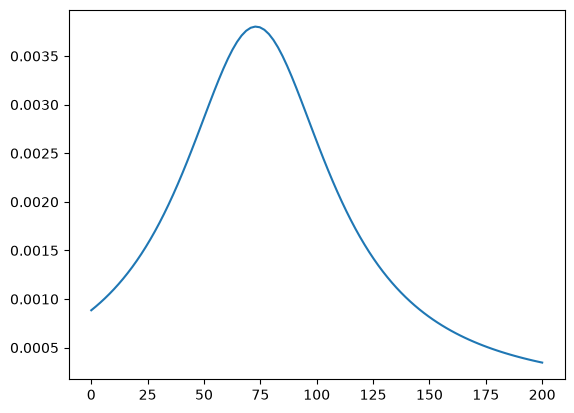

In [7]:
import matplotlib.pyplot as plt
config=SimConfig() 
alpha_deg = 8 * config.alpha_deg
tau_fc = 0.1*config.tau_fc

A = (config.a2 * (config.k_h2 / 1000.0)) + (config.k_fc * alpha_deg) / (3600.0 * tau_fc * (config.p_nom**2))
B = (config.a1 * (config.k_h2 / 1000.0)) - (2.0 * config.k_fc * alpha_deg) / (3600.0 * tau_fc * config.p_nom)
C = (config.a0 * (config.k_h2 / 1000.0)) + (config.k_fc / (3600.0 * tau_fc)) * (1.0 +  alpha_deg)

fig,ax = plt.subplots()
p = np.linspace(0, 200, 100)
c_fc=A * (p**2) + B * p + C
flow_rate = config.a2*p**2 + config.a1*p + config.a0
ax.plot(p,config.k_h2/(3600*config.LHV*c_fc))